# FOMC Announcements and the Overnight–Intraday Return Relationship in the U.S. Stock Market: Evidence from SPY

**Group 12 — Quantitative Methods for Finance (TCH442)**  
**Sample:** 2015–2025 | **Frequency:** Daily | **Main estimator:** OLS with Newey–West/HAC standard errors

## Objective

This notebook prepares the research dataset and examines whether scheduled FOMC announcement days are associated with a different relationship between SPY's overnight and intraday returns.

The analysis is **associational, not causal**. FOMC decisions respond to macroeconomic conditions that can also affect financial markets.

### Success criteria

1. Build a reproducible, validated market–FOMC dataset.
2. Estimate the three pre-specified models with HAC inference.
3. Produce an event-window visualization and robustness checks.
4. Interpret statistical and economic significance next to each result.

## Research design

For trading day (t):

$$r^{ON}_t=\ln(Open_t/Close_{t-1}), \qquad
r^{ID}_t=\ln(Close_t/Open_t).$$

The primary model is

$$r^{ID}_t=\alpha+\beta r^{ON}_t+\gamma FOMC_t
+\delta(r^{ON}_t\times FOMC_t)+\theta'Controls_t+\varepsilon_t.$$

- ‎(eta): continuation/reversal on ordinary days.
- ‎(gamma): FOMC-day shift when overnight return equals zero.
- ‎(delta): change in the overnight–intraday relationship on FOMC days.

Models 2 and 3 respectively examine absolute intraday returns and differences among `hike`, `cut`, and `hold` decisions.

## 1. Setup and reproducibility

In [1]:
from io import StringIO
from pathlib import Path
import re
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import statsmodels.formula.api as smf
import yfinance as yf
from bs4 import BeautifulSoup
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
plt.style.use("seaborn-v0_8-whitegrid")

SEED = 12
np.random.seed(SEED)

START_DATE = "2015-01-01"
END_DATE = "2025-12-31"
DOWNLOAD_START = "2014-12-15"  # supplies the prior close for the first return
DOWNLOAD_END = "2026-01-02"    # yfinance end date is exclusive
HAC_LAGS = 5
REFRESH_DATA = False

PROJECT_ROOT = Path.cwd()
RAW_DIR = PROJECT_ROOT / "data/raw"
PROCESSED_DIR = PROJECT_ROOT / "data/processed"
FIGURE_DIR = PROJECT_ROOT / "outputs/figures"
TABLE_DIR = PROJECT_ROOT / "outputs/tables"
for directory in [RAW_DIR, PROCESSED_DIR, FIGURE_DIR, TABLE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("yfinance:", yf.__version__)
print("pandas:", pd.__version__)

Project root: /Users/admin/Documents/TCH442_Group12/fomc-price-discovery/output/jupyter-notebook
yfinance: 0.2.66
pandas: 2.2.3


## 2. Download market data

SPY is downloaded with `auto_adjust=True`, so its Open and Close fields are adjusted consistently for corporate actions. Dividend amounts are retained separately to support the ex-dividend robustness check. VIX is used only as a lagged control for prevailing market uncertainty.

Raw downloads are cached in `data/raw/`; set `REFRESH_DATA=True` to download them again.

In [2]:
spy_path = RAW_DIR / "spy_daily_2014_2025.csv"
vix_path = RAW_DIR / "vix_daily_2014_2025.csv"

def download_one(ticker):
    frame = yf.download(
        ticker,
        start=DOWNLOAD_START,
        end=DOWNLOAD_END,
        auto_adjust=True,
        actions=True,
        progress=False,
        threads=False,
        multi_level_index=False,
    )
    if frame.empty:
        raise RuntimeError(f"No data returned for {ticker}.")
    frame.index = pd.to_datetime(frame.index).tz_localize(None)
    frame.index.name = "Date"
    return frame

if REFRESH_DATA or not spy_path.exists():
    spy_raw = download_one("SPY")
    spy_raw.to_csv(spy_path)
else:
    spy_raw = pd.read_csv(spy_path, parse_dates=["Date"], index_col="Date")

if REFRESH_DATA or not vix_path.exists():
    vix_raw = download_one("^VIX")
    vix_raw.to_csv(vix_path)
else:
    vix_raw = pd.read_csv(vix_path, parse_dates=["Date"], index_col="Date")

market_check = pd.DataFrame({
    "first_date": [spy_raw.index.min(), vix_raw.index.min()],
    "last_date": [spy_raw.index.max(), vix_raw.index.max()],
    "rows": [len(spy_raw), len(vix_raw)],
    "missing_close": [spy_raw["Close"].isna().sum(), vix_raw["Close"].isna().sum()],
}, index=["SPY", "VIX"])
display(market_check)

,first_date,last_date,rows,missing_close
SPY,2014-12-15,2025-12-31,2778,0
VIX,2014-12-15,2025-12-31,2778,0


## 3. Build the scheduled FOMC calendar

Sources:

- [Federal Reserve historical material by year](https://www.federalreserve.gov/monetarypolicy/fomc_historical_year.htm), used for 2015–2020.
- [Federal Reserve meeting calendars](https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm), used for 2021–2025.
The parser keeps regular meetings with a published statement and excludes entries labeled `unscheduled`, `cancelled`, or `notation vote`. Scheduled rate-change dates and magnitudes are recorded explicitly from the Federal Reserve statements so the classification remains transparent and auditable without relying on a third-party API.

In [3]:
FED_BASE = "https://www.federalreserve.gov"
HEADERS = {"User-Agent": "TCH442 academic research project (Group 12)"}

def resilient_get(url, attempts=3, timeout=90):
    last_error = None
    for attempt in range(1, attempts + 1):
        try:
            response = requests.get(url, headers=HEADERS, timeout=timeout)
            response.raise_for_status()
            return response
        except requests.RequestException as error:
            last_error = error
            if attempt < attempts:
                time.sleep(2 * attempt)
    raise RuntimeError(f"Download failed after {attempts} attempts: {url}") from last_error

def get_soup(url):
    response = resilient_get(url)
    return BeautifulSoup(response.text, "html.parser")

def statement_date_from_link(link):
    match = re.search(r"monetary(\d{8})a\.htm", link.get("href", ""))
    return pd.to_datetime(match.group(1), format="%Y%m%d") if match else None

event_rows = []

# Historical year pages: use each regular meeting heading and its next statement link.
for year in range(2015, 2021):
    url = f"{FED_BASE}/monetarypolicy/fomchistorical{year}.htm"
    soup = get_soup(url)
    for heading in soup.select("h5"):
        label = heading.get_text(" ", strip=True)
        label_lower = label.lower()
        excluded = any(word in label_lower for word in ["unscheduled", "cancelled", "notation"])
        if "meeting" not in label_lower or excluded:
            continue
        link = heading.find_next(
            "a", href=re.compile(r"/newsevents/pressreleases/monetary\d{8}a\.htm")
        )
        date = statement_date_from_link(link) if link else None
        if date is not None and date.year == year:
            event_rows.append({"event_date": date, "source_url": url, "meeting_label": label})

# Current calendar page: identify the statement link inside each regular meeting row.
calendar_url = f"{FED_BASE}/monetarypolicy/fomccalendars.htm"
soup = get_soup(calendar_url)
for row in soup.select("div.fomc-meeting"):
    label = row.get_text(" ", strip=True)
    label_lower = label.lower()
    if any(word in label_lower for word in ["unscheduled", "cancelled", "notation vote"]):
        continue
    link = row.find(
        "a", href=re.compile(r"/newsevents/pressreleases/monetary\d{8}a\.htm")
    )
    date = statement_date_from_link(link) if link else None
    if date is not None and 2021 <= date.year <= 2025:
        event_rows.append({"event_date": date, "source_url": calendar_url, "meeting_label": label})

fomc = (
    pd.DataFrame(event_rows)
    .drop_duplicates("event_date")
    .sort_values("event_date")
    .reset_index(drop=True)
)

# Scheduled changes to the target-range upper limit, in percentage points.
# Emergency changes on 2020-03-03 and 2020-03-15 are intentionally omitted.
scheduled_rate_changes = {
    "2015-12-16": 0.25,
    "2016-12-14": 0.25,
    "2017-03-15": 0.25, "2017-06-14": 0.25, "2017-12-13": 0.25,
    "2018-03-21": 0.25, "2018-06-13": 0.25, "2018-09-26": 0.25, "2018-12-19": 0.25,
    "2019-07-31": -0.25, "2019-09-18": -0.25, "2019-10-30": -0.25,
    "2022-03-16": 0.25, "2022-05-04": 0.50, "2022-06-15": 0.75,
    "2022-07-27": 0.75, "2022-09-21": 0.75, "2022-11-02": 0.75, "2022-12-14": 0.50,
    "2023-02-01": 0.25, "2023-03-22": 0.25, "2023-05-03": 0.25, "2023-07-26": 0.25,
    "2024-09-18": -0.50, "2024-11-07": -0.25, "2024-12-18": -0.25,
    "2025-09-17": -0.25, "2025-10-29": -0.25, "2025-12-10": -0.25,
}
scheduled_rate_changes = {
    pd.Timestamp(date): change for date, change in scheduled_rate_changes.items()
}
fomc["rate_change"] = fomc["event_date"].map(scheduled_rate_changes).fillna(0.0)
fomc["decision"] = np.select(
    [fomc["rate_change"] > 1e-9, fomc["rate_change"] < -1e-9],
    ["hike", "cut"],
    default="hold",
)
fomc.to_csv(RAW_DIR / "fomc_scheduled_events_2015_2025.csv", index=False)

calendar_check = fomc.groupby([fomc["event_date"].dt.year, "decision"]).size().unstack(fill_value=0)
display(calendar_check)
print(f"Scheduled events: {len(fomc)}")

assert len(fomc) == 87, "Expected 87 scheduled announcement dates in 2015–2025."
assert fomc["event_date"].is_unique
assert set(scheduled_rate_changes).issubset(set(fomc["event_date"]))

decision,cut,hike,hold
event_date,,,
2015,0,1,7
2016,0,1,7
2017,0,3,5
2018,0,4,4
2019,3,0,5
2020,0,0,7
2021,0,0,8
2022,0,7,1
2023,0,4,4


Scheduled events: 87


## 4. Prepare and validate the analysis dataset

In [4]:
market = spy_raw[["Open", "High", "Low", "Close", "Volume", "Dividends"]].copy()
market = market.rename(columns={
    "Open": "spy_open",
    "High": "spy_high",
    "Low": "spy_low",
    "Close": "spy_close",
    "Volume": "spy_volume",
    "Dividends": "spy_dividend",
})
market["vix_close"] = vix_raw["Close"]

# Record sample attrition before transforming or dropping rows.
market_window = market.loc[START_DATE:END_DATE].copy()
rows_in_date_window = len(market_window)
rows_after_spy_vix_alignment = int(
    market_window[["spy_open", "spy_close", "vix_close"]].notna().all(axis=1).sum()
)

market["overnight_return"] = np.log(market["spy_open"] / market["spy_close"].shift(1))
market["intraday_return"] = np.log(market["spy_close"] / market["spy_open"])
market["close_return"] = np.log(market["spy_close"] / market["spy_close"].shift(1))
market["abs_intraday_return"] = market["intraday_return"].abs()
market["abs_overnight_return"] = market["overnight_return"].abs()
market["lagged_return"] = market["close_return"].shift(1)
market["lagged_abs_return"] = market["close_return"].abs().shift(1)
market["lagged_log_vix"] = np.log(market["vix_close"]).shift(1)
market["ex_dividend"] = (market["spy_dividend"].fillna(0) > 0).astype(int)
market["day_of_week"] = market.index.dayofweek
market["month"] = market.index.month

analysis = market.loc[START_DATE:END_DATE].copy()
event_info = fomc.set_index("event_date")[["decision", "rate_change"]]
analysis = analysis.join(event_info, how="left")
analysis["fomc_day"] = analysis["decision"].notna().astype(int)
for decision in ["hike", "cut", "hold"]:
    analysis[decision] = analysis["decision"].eq(decision).astype(int)

# 2020-03-15 was a Sunday; its market impact is assigned to Monday 2020-03-16.
emergency_market_dates = pd.to_datetime(["2020-03-03", "2020-03-16"])
analysis["emergency_fomc"] = analysis.index.isin(emergency_market_dates).astype(int)

# Standardize lagged log VIX: the coefficient represents a one-SD change.
analysis["lagged_vix_z"] = (
    analysis["lagged_log_vix"] - analysis["lagged_log_vix"].mean()
) / analysis["lagged_log_vix"].std()

required = [
    "spy_open", "spy_high", "spy_low", "spy_close", "spy_volume", "vix_close",
    "overnight_return", "intraday_return", "close_return",
    "lagged_return", "lagged_abs_return", "lagged_vix_z",
]
rows_before_complete_case = len(analysis)
missing_required_before_drop = analysis[required].isna().sum()
analysis = analysis.dropna(subset=required)
analysis.index.name = "Date"

# Keep the full cleaned dataset, but remove emergency-event impact dates from baseline models.
model_sample = analysis.loc[analysis["emergency_fomc"] == 0].copy()
analysis.to_csv(PROCESSED_DIR / "spy_fomc_analysis_2015_2025.csv")

checks = pd.Series({
    "Clean observations": len(analysis),
    "Baseline observations after emergency exclusion": len(model_sample),
    "First trading date": analysis.index.min().date(),
    "Last trading date": analysis.index.max().date(),
    "Scheduled FOMC trading days": int(model_sample["fomc_day"].sum()),
    "Hikes": int(model_sample["hike"].sum()),
    "Cuts": int(model_sample["cut"].sum()),
    "Holds": int(model_sample["hold"].sum()),
    "Emergency FOMC market-impact dates": int(analysis["emergency_fomc"].sum()),
    "SPY ex-dividend days": int(model_sample["ex_dividend"].sum()),
    "Duplicate dates": int(analysis.index.duplicated().sum()),
})
display(checks.to_frame("Value"))

assert analysis.index.is_monotonic_increasing
assert not analysis.index.duplicated().any()
assert analysis[required].notna().all().all()
assert model_sample["fomc_day"].sum() == len(fomc)
assert analysis["emergency_fomc"].sum() == 2

,Value
Clean observations,2766
Baseline observations after emergency exclusion,2764
First trading date,2015-01-02
Last trading date,2025-12-31
Scheduled FOMC trading days,87
Hikes,20
Cuts,9
Holds,58
Emergency FOMC market-impact dates,2
SPY ex-dividend days,44


### 4.1 Data-cleaning audit

The baseline does **not** mechanically delete large financial returns. Crisis observations can be genuine information rather than data errors. Instead, the notebook reports extreme observations, measures regression influence with Cook's distance, and treats their exclusion only as a robustness check.

Emergency policy actions are handled separately from scheduled FOMC meetings:

- `2020-03-03`: emergency intermeeting cut on a trading day.
- `2020-03-16`: first trading session after the emergency Sunday announcement on `2020-03-15`.

Both observations remain in the saved clean dataset with `emergency_fomc=1`, but are excluded from the baseline estimation sample so they are not incorrectly treated as ordinary days.

In [5]:
ohlc_invalid = (
    (analysis["spy_high"] < analysis[["spy_open", "spy_close"]].max(axis=1))
    | (analysis["spy_low"] > analysis[["spy_open", "spy_close"]].min(axis=1))
)

quality_audit = pd.DataFrame({
    "Check": [
        "Duplicate dates",
        "Missing required values after cleaning",
        "Infinite numeric values",
        "Non-positive SPY Open/High/Low/Close",
        "Non-positive VIX",
        "Negative SPY volume",
        "Invalid OHLC ordering",
        "Return decomposition failures",
        "Scheduled FOMC dates missing from trading data",
    ],
    "Problems found": [
        int(analysis.index.duplicated().sum()),
        int(analysis[required].isna().sum().sum()),
        int(np.isinf(analysis.select_dtypes("number")).sum().sum()),
        int((analysis[["spy_open", "spy_high", "spy_low", "spy_close"]] <= 0).sum().sum()),
        int((analysis["vix_close"] <= 0).sum()),
        int((analysis["spy_volume"] < 0).sum()),
        int(ohlc_invalid.sum()),
        int(((analysis["close_return"] - analysis["overnight_return"] - analysis["intraday_return"]).abs() > 1e-10).sum()),
        int(len(set(fomc["event_date"]) - set(analysis.index))),
    ],
})
quality_audit["Status"] = np.where(quality_audit["Problems found"] == 0, "PASS", "REVIEW")
display(quality_audit)

attrition = pd.DataFrame({
    "Stage": [
        "Trading days inside 2015–2025",
        "After SPY–VIX date alignment",
        "After return/lag construction and complete-case cleaning",
        "Baseline after excluding emergency FOMC impact dates",
    ],
    "Rows": [
        rows_in_date_window,
        rows_after_spy_vix_alignment,
        len(analysis),
        len(model_sample),
    ],
})
attrition["Rows removed at stage"] = -attrition["Rows"].diff().fillna(0).astype(int)
display(attrition)

missing_before = missing_required_before_drop[missing_required_before_drop > 0].to_frame("Missing before drop")
display(missing_before if not missing_before.empty else Markdown("No required-variable missing values before cleaning."))

extreme_observations = pd.concat([
    analysis.nlargest(5, "abs_overnight_return").assign(flag="Largest absolute overnight"),
    analysis.nlargest(5, "abs_intraday_return").assign(flag="Largest absolute intraday"),
])[["flag", "overnight_return", "intraday_return", "close_return", "fomc_day", "emergency_fomc"]]
display(extreme_observations)

assert quality_audit["Problems found"].sum() == 0

,Check,Problems found,Status
0,Duplicate dates,0,PASS
1,Missing required values after cleaning,0,PASS
2,Infinite numeric values,0,PASS
3,Non-positive SPY Open/High/Low/Close,0,PASS
4,Non-positive VIX,0,PASS
5,Negative SPY volume,0,PASS
6,Invalid OHLC ordering,0,PASS
7,Return decomposition failures,0,PASS
8,Scheduled FOMC dates missing from trading data,0,PASS


,Stage,Rows,Rows removed at stage
0,Trading days inside 2015–2025,2766,0
1,After SPY–VIX date alignment,2766,0
2,After return/lag construction and complete-cas...,2766,0
3,Baseline after excluding emergency FOMC impact...,2764,2


No required-variable missing values before cleaning.

,flag,overnight_return,intraday_return,close_return,fomc_day,emergency_fomc
Date,,,,,,
2020-03-16,Largest absolute overnight,-0.110357,-0.005530,-0.115887,0,1
2020-03-09,Largest absolute overnight,-0.077418,-0.003894,-0.081312,0,0
2020-03-12,Largest absolute overnight,-0.069263,-0.031305,-0.100569,0,0
2020-03-18,Largest absolute overnight,-0.067708,0.015748,-0.051960,0,0
2020-03-13,Largest absolute overnight,0.058624,0.023404,0.082028,0,0
2025-04-09,Largest absolute intraday,-0.006142,0.106005,0.099863,0,0
2020-03-20,Largest absolute intraday,0.014227,-0.058277,-0.044050,0,0
2025-04-08,Largest absolute intraday,0.034069,-0.049856,-0.015787,0,0
2022-10-13,Largest absolute intraday,-0.020830,0.046878,0.026048,0,0


## 5. Descriptive statistics

In [6]:
summary = analysis[[
    "overnight_return", "intraday_return", "close_return",
    "abs_intraday_return", "vix_close", "spy_volume",
]].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T
display(summary)

group_summary = model_sample.groupby("fomc_day").agg(
    observations=("intraday_return", "size"),
    mean_overnight=("overnight_return", "mean"),
    mean_intraday=("intraday_return", "mean"),
    mean_abs_intraday=("abs_intraday_return", "mean"),
    median_vix=("vix_close", "median"),
)
for col in ["mean_overnight", "mean_intraday", "mean_abs_intraday"]:
    group_summary[col] *= 10_000
group_summary = group_summary.rename(index={0: "Non-FOMC", 1: "FOMC"})
display(group_summary.style.format({
    "observations": "{:,.0f}",
    "mean_overnight": "{:.2f} bp",
    "mean_intraday": "{:.2f} bp",
    "mean_abs_intraday": "{:.2f} bp",
    "median_vix": "{:.2f}",
}))

diff_intraday = group_summary.loc["FOMC", "mean_intraday"] - group_summary.loc["Non-FOMC", "mean_intraday"]
diff_abs = group_summary.loc["FOMC", "mean_abs_intraday"] - group_summary.loc["Non-FOMC", "mean_abs_intraday"]
display(Markdown(
    f"**Descriptive reading.** Scheduled FOMC days have an average intraday return "
    f"that is **{diff_intraday:+.2f} basis points** relative to ordinary days. "
    f"Their average absolute intraday return differs by **{diff_abs:+.2f} basis points**. "
    "These are unconditional differences and should not be interpreted as causal or as regression evidence."
))

,count,mean,std,min,1%,25%,50%,75%,99%,max
overnight_return,"2,766.000000",0.000330,0.007295,-0.110357,-0.020653,-0.002205,0.000617,0.003397,0.018173,0.058624
intraday_return,"2,766.000000",0.000171,0.008448,-0.058277,-0.025224,-0.003309,0.000505,0.004297,0.021501,0.106005
close_return,"2,766.000000",0.000501,0.011230,-0.115887,-0.032680,-0.003709,0.000633,0.005905,0.025914,0.099863
abs_intraday_return,"2,766.000000",0.005675,0.006260,0.000000,0.000039,0.001651,0.003887,0.007609,0.029781,0.106005
vix_close,"2,766.000000",18.331316,7.129529,9.140000,9.702500,13.552500,16.520000,21.247500,42.459499,82.690002
spy_volume,"2,766.000000","86,081,060.484454","43,925,193.016033","20,270,000.000000","32,792,175.000000","58,748,425.000000","75,707,800.000000","99,419,750.000000","257,911,470.000000","507,244,300.000000"


,observations,mean_overnight,mean_intraday,mean_abs_intraday,median_vix
fomc_day,,,,,
Non-FOMC,"2,677",3.26 bp,2.10 bp,56.29 bp,16.52
FOMC,87,16.92 bp,-6.05 bp,68.19 bp,16.36


**Descriptive reading.** Scheduled FOMC days have an average intraday return that is **-8.15 basis points** relative to ordinary days. Their average absolute intraday return differs by **+11.90 basis points**. These are unconditional differences and should not be interpreted as causal or as regression evidence.

## 6. Estimation helpers

All main models use OLS point estimates with HAC/Newey–West standard errors (`maxlags=5`). The HAC correction allows both heteroskedasticity and short-run residual autocorrelation.

In [7]:
def fit_hac(formula, data, lags=HAC_LAGS):
    return smf.ols(formula, data=data).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": lags, "use_correction": True},
    )

def result_table(result, terms):
    ci = result.conf_int()
    table = pd.DataFrame({
        "coefficient": result.params,
        "HAC SE": result.bse,
        "t": result.tvalues,
        "p-value": result.pvalues,
        "CI 2.5%": ci[0],
        "CI 97.5%": ci[1],
    })
    return table.loc[terms]

def significance_text(p):
    if p < 0.01:
        return "statistically significant at 1%"
    if p < 0.05:
        return "statistically significant at 5%"
    if p < 0.10:
        return "marginally significant at 10%"
    return "not statistically significant at 10%"

calendar_controls = "lagged_return + lagged_vix_z + C(day_of_week) + C(month)"

## 7. Model 1 — Overnight–intraday price discovery

In [8]:
formula_1 = (
    "intraday_return ~ overnight_return + fomc_day "
    "+ overnight_return:fomc_day + " + calendar_controls
)
model_1 = fit_hac(formula_1, model_sample)
terms_1 = ["overnight_return", "fomc_day", "overnight_return:fomc_day", "lagged_return", "lagged_vix_z"]
table_1 = result_table(model_1, terms_1)
display(table_1)
table_1.to_csv(TABLE_DIR / "model_1_price_discovery.csv")

beta = model_1.params["overnight_return"]
gamma = model_1.params["fomc_day"]
delta = model_1.params["overnight_return:fomc_day"]
p_delta = model_1.pvalues["overnight_return:fomc_day"]
fomc_slope_test = model_1.t_test("overnight_return + overnight_return:fomc_day = 0")
fomc_slope = beta + delta
fomc_slope_p = float(np.asarray(fomc_slope_test.pvalue).squeeze())

normal_pattern = "continuation" if beta > 0 else "reversal"
fomc_pattern = "continuation" if fomc_slope > 0 else "reversal"
display(Markdown(
    f"""### Interpretation — Model 1

- On non-FOMC days, the overnight–intraday slope is **{beta:.3f}**, indicating **{normal_pattern}** on average.
- On FOMC days, the implied slope is **{fomc_slope:.3f}** (linear-combination p-value = **{fomc_slope_p:.3f}**), indicating **{fomc_pattern}**.
- The interaction estimate is **{delta:.3f}** and is **{significance_text(p_delta)}** (p = **{p_delta:.3f}**). This is the direct test of whether the relationship changes on scheduled announcement days.
- Holding controls fixed and evaluating at zero overnight return, the FOMC-day level shift is **{gamma * 10_000:+.2f} basis points**.

The coefficients describe conditional associations. They do not isolate an exogenous monetary-policy shock.
"""
))

,coefficient,HAC SE,t,p-value,CI 2.5%,CI 97.5%
overnight_return,0.004741,0.045941,0.103190,0.917812,-0.085303,0.094784
fomc_day,-0.001285,0.001141,-1.126257,0.260057,-0.003523,0.000952
overnight_return:fomc_day,0.191906,0.243060,0.789541,0.429796,-0.284483,0.668294
lagged_return,-0.039712,0.024960,-1.591023,0.111604,-0.088632,0.009209
lagged_vix_z,0.000298,0.000201,1.479913,0.138897,-0.000097,0.000692


### Interpretation — Model 1

- On non-FOMC days, the overnight–intraday slope is **0.005**, indicating **continuation** on average.
- On FOMC days, the implied slope is **0.197** (linear-combination p-value = **0.414**), indicating **continuation**.
- The interaction estimate is **0.192** and is **not statistically significant at 10%** (p = **0.430**). This is the direct test of whether the relationship changes on scheduled announcement days.
- Holding controls fixed and evaluating at zero overnight return, the FOMC-day level shift is **-12.85 basis points**.

The coefficients describe conditional associations. They do not isolate an exogenous monetary-policy shock.


### 7.1 Outlier and influence diagnostics

Large returns are not automatically errors. Cook's distance measures how strongly each observation affects the fitted OLS coefficients. The conventional screening threshold `4/n` flags observations for review; it is not a deletion rule.

,overnight_return,intraday_return,close_return,fomc_day,cooks_distance
Date,,,,,
2025-04-09,-0.006142,0.106005,0.099863,0,0.079064
2020-03-12,-0.069263,-0.031305,-0.100569,0,0.048235
2022-01-26,0.014283,-0.016795,-0.002512,1,0.037146
2020-03-20,0.014227,-0.058277,-0.044050,0,0.033872
2025-04-08,0.034069,-0.049856,-0.015787,0,0.030460
2015-08-25,0.030814,-0.042651,-0.011837,0,0.026732
2020-04-07,0.034693,-0.033674,0.001019,0,0.024106
2020-03-24,0.050166,0.036564,0.086731,0,0.023973
2020-03-17,0.021408,0.031177,0.052585,0,0.022937


Cook's distance threshold: 0.001447
Flagged observations: 167 (6.04% of baseline sample)


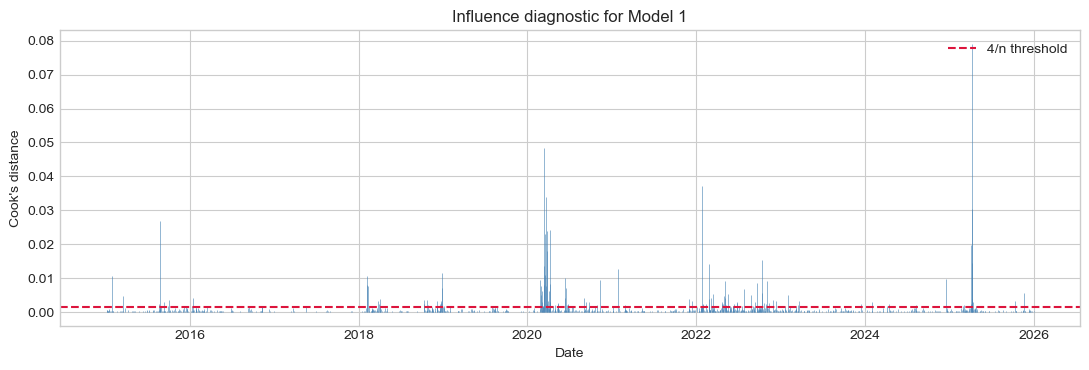

In [9]:
influence_ols = smf.ols(formula_1, data=model_sample).fit()
influence = influence_ols.get_influence()
cooks_d = pd.Series(influence.cooks_distance[0], index=model_sample.index, name="cooks_distance")
cooks_threshold = 4 / len(model_sample)
influential_dates = cooks_d.index[cooks_d > cooks_threshold]

influence_table = (
    model_sample[["overnight_return", "intraday_return", "close_return", "fomc_day"]]
    .join(cooks_d)
    .sort_values("cooks_distance", ascending=False)
    .head(12)
)
display(influence_table)
print(f"Cook's distance threshold: {cooks_threshold:.6f}")
print(f"Flagged observations: {len(influential_dates)} ({len(influential_dates)/len(model_sample):.2%} of baseline sample)")

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.vlines(cooks_d.index, 0, cooks_d, color="steelblue", linewidth=0.55, alpha=0.75)
ax.axhline(cooks_threshold, color="crimson", linestyle="--", label="4/n threshold")
ax.set(title="Influence diagnostic for Model 1", xlabel="Date", ylabel="Cook's distance")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_1_cooks_distance.png", dpi=180, bbox_inches="tight")
plt.show()

## 8. Model 2 — Intraday volatility

In [10]:
formula_2 = (
    "abs_intraday_return ~ fomc_day + abs_overnight_return "
    "+ lagged_abs_return + lagged_vix_z + C(day_of_week) + C(month)"
)
model_2 = fit_hac(formula_2, model_sample)
terms_2 = ["fomc_day", "abs_overnight_return", "lagged_abs_return", "lagged_vix_z"]
table_2 = result_table(model_2, terms_2)
display(table_2)
table_2.to_csv(TABLE_DIR / "model_2_intraday_volatility.csv")

vol_effect = model_2.params["fomc_day"] * 10_000
vol_p = model_2.pvalues["fomc_day"]
direction = "higher" if vol_effect > 0 else "lower"
display(Markdown(
    f"""### Interpretation — Model 2

After controlling for overnight movement, lagged volatility, VIX and calendar effects, scheduled FOMC days are associated with **{abs(vol_effect):.2f} basis points {direction}** absolute intraday return. The estimate is **{significance_text(vol_p)}** using five HAC lags (p = **{vol_p:.3f}**). The result is close to the 5% threshold; the bandwidth sensitivity table below is essential to its interpretation.

This coefficient measures a difference in realized intraday movement, not a structural measure of uncertainty and not a causal treatment effect.
"""
))

,coefficient,HAC SE,t,p-value,CI 2.5%,CI 97.5%
fomc_day,0.001342,0.000682,1.967859,0.049084,0.000005,0.002679
abs_overnight_return,0.143133,0.036972,3.871434,0.000108,0.070670,0.215596
lagged_abs_return,-0.004265,0.023298,-0.183072,0.854741,-0.049928,0.041397
lagged_vix_z,0.002578,0.000260,9.928337,0.000000,0.002069,0.003087


### Interpretation — Model 2

After controlling for overnight movement, lagged volatility, VIX and calendar effects, scheduled FOMC days are associated with **13.42 basis points higher** absolute intraday return. The estimate is **statistically significant at 5%** using five HAC lags (p = **0.049**). The result is close to the 5% threshold; the bandwidth sensitivity table below is essential to its interpretation.

This coefficient measures a difference in realized intraday movement, not a structural measure of uncertainty and not a causal treatment effect.


## 9. Model 3 — Hike, cut, and hold decisions

In [11]:
formula_3 = (
    "intraday_return ~ overnight_return + hike + cut + hold "
    "+ overnight_return:hike + overnight_return:cut + overnight_return:hold "
    "+ " + calendar_controls
)
model_3 = fit_hac(formula_3, model_sample)
terms_3 = [
    "overnight_return", "hike", "cut", "hold",
    "overnight_return:hike", "overnight_return:cut", "overnight_return:hold",
]
table_3 = result_table(model_3, terms_3)
display(table_3)
table_3.to_csv(TABLE_DIR / "model_3_decision_types.csv")

interpretation_lines = []
for decision in ["hike", "cut", "hold"]:
    level_bp = model_3.params[decision] * 10_000
    level_p = model_3.pvalues[decision]
    interaction = model_3.params[f"overnight_return:{decision}"]
    interaction_p = model_3.pvalues[f"overnight_return:{decision}"]
    n_events = int(model_sample[decision].sum())
    interpretation_lines.append(
        f"- **{decision.title()} ({n_events} events):** conditional intraday shift "
        f"= **{level_bp:+.2f} bp** (p = {level_p:.3f}); slope change "
        f"= **{interaction:+.3f}** (p = {interaction_p:.3f})."
    )

display(Markdown(
    "### Interpretation — Model 3\n\n" + "\n".join(interpretation_lines) +
    "\n\nSubgroup estimates should be interpreted cautiously because the number of "
    "rate changes is much smaller than the number of hold decisions. Hike/cut/hold "
    "also does not measure whether the decision surprised the market."
))

,coefficient,HAC SE,t,p-value,CI 2.5%,CI 97.5%
overnight_return,0.004729,0.045953,0.102909,0.918035,-0.085338,0.094796
hike,-0.003534,0.003216,-1.098832,0.271841,-0.009838,0.002770
cut,-0.004242,0.004822,-0.879742,0.378999,-0.013693,0.005209
hold,-0.000417,0.001124,-0.370649,0.710899,-0.002621,0.001787
overnight_return:hike,1.154261,0.652541,1.768871,0.076915,-0.124696,2.433219
overnight_return:cut,1.208814,2.164603,0.558446,0.576540,-3.033730,5.451358
overnight_return:hold,-0.022823,0.259969,-0.087792,0.930042,-0.532353,0.486706


### Interpretation — Model 3

- **Hike (20 events):** conditional intraday shift = **-35.34 bp** (p = 0.272); slope change = **+1.154** (p = 0.077).
- **Cut (9 events):** conditional intraday shift = **-42.42 bp** (p = 0.379); slope change = **+1.209** (p = 0.577).
- **Hold (58 events):** conditional intraday shift = **-4.17 bp** (p = 0.711); slope change = **-0.023** (p = 0.930).

Subgroup estimates should be interpreted cautiously because the number of rate changes is much smaller than the number of hold decisions. Hike/cut/hold also does not measure whether the decision surprised the market.

### 9.1 Joint Wald tests for policy decision groups

In [12]:
# Joint and equality restrictions use the same HAC covariance as Model 3.
joint_hypotheses = {
    "All three slope shifts equal zero": (
        "overnight_return:hike = 0, overnight_return:cut = 0, "
        "overnight_return:hold = 0"
    ),
    "All three level shifts equal zero": "hike = 0, cut = 0, hold = 0",
    "Level shifts equal across decisions": "hike = cut, cut = hold",
    "Slope shifts equal across decisions": (
        "overnight_return:hike = overnight_return:cut, "
        "overnight_return:cut = overnight_return:hold"
    ),
}
joint_rows = []
for label, hypothesis in joint_hypotheses.items():
    test = model_3.wald_test(hypothesis, scalar=True)
    joint_rows.append({"hypothesis": label, "Wald chi2": float(test.statistic),
                       "df": len(hypothesis.split(",")), "p-value": float(test.pvalue)})
joint_tests_table = pd.DataFrame(joint_rows)
display(joint_tests_table)
joint_tests_table.to_csv(TABLE_DIR / "model_3_joint_wald_tests.csv", index=False)
display(Markdown(
    "**Interpretation.** None of the joint restrictions is rejected at 5%. "
    "An isolated subgroup p-value near 0.10 is not sufficient evidence that "
    "hikes, cuts and holds differ overall; the cut group contains only nine events."
))

,hypothesis,Wald chi2,df,p-value
0,All three slope shifts equal zero,3.446086,3,0.327822
1,All three level shifts equal zero,2.030723,3,0.566055
2,Level shifts equal across decisions,1.380609,2,0.501423
3,Slope shifts equal across decisions,3.087292,2,0.213601


**Interpretation.** None of the joint restrictions is rejected at 5%. An isolated subgroup p-value near 0.10 is not sufficient evidence that hikes, cuts and holds differ overall; the cut group contains only nine events.

## 10. Event window `[-2, +2]`

,events,mean_overnight,mean_intraday,mean_close,se_close,cumulative_mean_close,mean_overnight_bp,mean_intraday_bp,mean_close_bp
relative_day,,,,,,,,,
-2,87,-0.000653,0.000918,0.000265,0.000937,0.000265,-6.528978,9.183399,2.654422
-1,87,0.001164,-0.000038,0.001126,0.000853,0.001392,11.641213,-0.377907,11.263306
0,87,0.001692,-0.000605,0.001086,0.001160,0.002478,16.917308,-6.054258,10.863049
1,87,-0.000349,-0.001298,-0.001647,0.001288,0.000831,-3.486041,-12.984672,-16.470713
2,87,0.000390,-0.001427,-0.001037,0.001156,-0.000206,3.898973,-14.271676,-10.372704


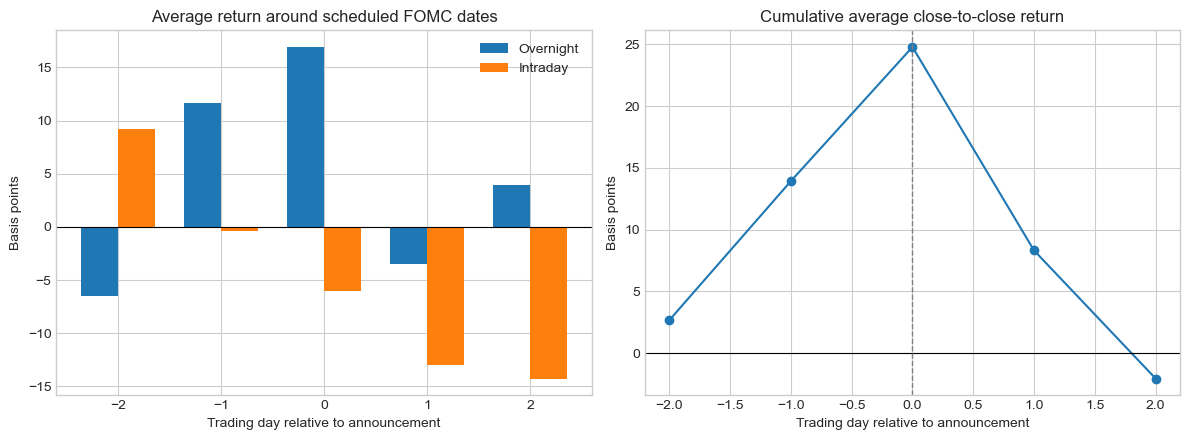

**Event-window reading.** Across **87 scheduled events**, announcement-day average overnight return is **+16.92 bp** and average intraday return is **-6.05 bp**. The plot is descriptive: overlapping macroeconomic news and cross-event dependence are not removed.

In [13]:
event_frames = []
for event_date in fomc["event_date"]:
    if event_date not in analysis.index:
        continue
    event_position = analysis.index.get_loc(event_date)
    if event_position < 2 or event_position + 2 >= len(analysis):
        continue
    window = analysis.iloc[event_position - 2:event_position + 3][
        ["overnight_return", "intraday_return", "close_return"]
    ].copy()
    window["relative_day"] = range(-2, 3)
    window["event_date"] = event_date
    event_frames.append(window.reset_index())

event_panel = pd.concat(event_frames, ignore_index=True)
event_summary = event_panel.groupby("relative_day").agg(
    events=("event_date", "nunique"),
    mean_overnight=("overnight_return", "mean"),
    mean_intraday=("intraday_return", "mean"),
    mean_close=("close_return", "mean"),
    se_close=("close_return", "sem"),
)
event_summary["cumulative_mean_close"] = event_summary["mean_close"].cumsum()
display(event_summary.assign(
    mean_overnight_bp=event_summary["mean_overnight"] * 10_000,
    mean_intraday_bp=event_summary["mean_intraday"] * 10_000,
    mean_close_bp=event_summary["mean_close"] * 10_000,
))
event_summary.to_csv(TABLE_DIR / "event_window_summary.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
width = 0.36
x = event_summary.index.to_numpy()
axes[0].bar(x - width/2, event_summary["mean_overnight"] * 10_000, width, label="Overnight")
axes[0].bar(x + width/2, event_summary["mean_intraday"] * 10_000, width, label="Intraday")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set(title="Average return around scheduled FOMC dates", xlabel="Trading day relative to announcement", ylabel="Basis points")
axes[0].legend()

axes[1].plot(x, event_summary["cumulative_mean_close"] * 10_000, marker="o")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].axvline(0, color="gray", linestyle="--", linewidth=1)
axes[1].set(title="Cumulative average close-to-close return", xlabel="Trading day relative to announcement", ylabel="Basis points")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "fomc_event_window.png", dpi=180, bbox_inches="tight")
plt.show()

day0 = event_summary.loc[0]
display(Markdown(
    f"**Event-window reading.** Across **{int(day0['events'])} scheduled events**, "
    f"announcement-day average overnight return is **{day0['mean_overnight']*10_000:+.2f} bp** "
    f"and average intraday return is **{day0['mean_intraday']*10_000:+.2f} bp**. "
    "The plot is descriptive: overlapping macroeconomic news and cross-event dependence are not removed."
))

## 11. Pre-specified robustness checks

In [14]:
# Check A: include emergency-event impact dates to measure contamination sensitivity.
model_with_emergency = fit_hac(formula_1, analysis)

# Check B: remove SPY ex-dividend dates from the already-clean baseline sample.
model_no_dividend = fit_hac(formula_1, model_sample.loc[model_sample["ex_dividend"] == 0])

# Check C: remove Cook's-distance flagged observations only as a sensitivity analysis.
model_no_influential = fit_hac(formula_1, model_sample.drop(index=influential_dates))

# Check D: estimate the baseline separately before and after 2020.
model_pre2020 = fit_hac(formula_1, model_sample.loc[:"2019-12-31"])
model_post2020 = fit_hac(formula_1, model_sample.loc["2020-01-01":])

key_terms = ["fomc_day", "overnight_return:fomc_day"]
robustness_rows = []
for label, result in {
    "Baseline: emergency impacts excluded": model_1,
    "Emergency impacts included": model_with_emergency,
    "Exclude ex-dividend dates": model_no_dividend,
    "Exclude Cook-flagged observations": model_no_influential,
    "2015–2019": model_pre2020,
    "2020–2025": model_post2020,
}.items():
    for term in key_terms:
        robustness_rows.append({
            "sample": label,
            "term": term,
            "coefficient": result.params[term],
            "HAC SE": result.bse[term],
            "p-value": result.pvalues[term],
            "n": int(result.nobs),
        })

robustness = pd.DataFrame(robustness_rows)
display(robustness)
robustness.to_csv(TABLE_DIR / "model_1_robustness.csv", index=False)

baseline_delta = model_1.params["overnight_return:fomc_day"]
emergency_delta = model_with_emergency.params["overnight_return:fomc_day"]
no_div_delta = model_no_dividend.params["overnight_return:fomc_day"]
no_influence_delta = model_no_influential.params["overnight_return:fomc_day"]
pre_delta = model_pre2020.params["overnight_return:fomc_day"]
post_delta = model_post2020.params["overnight_return:fomc_day"]

same_div_sign = np.sign(baseline_delta) == np.sign(no_div_delta)
same_influence_sign = np.sign(baseline_delta) == np.sign(no_influence_delta)
same_period_sign = np.sign(pre_delta) == np.sign(post_delta)
display(Markdown(
    f"""### Interpretation — robustness

- Correctly excluding emergency-impact dates changes the interaction from **{emergency_delta:+.3f}** to the baseline value **{baseline_delta:+.3f}**.
- Removing ex-dividend dates **{'preserves' if same_div_sign else 'changes'}** its sign: **{no_div_delta:+.3f}**.
- Removing Cook-flagged observations **{'preserves' if same_influence_sign else 'changes'}** its sign and produces **{no_influence_delta:+.3f}**. This is sensitivity evidence, not a preferred trimmed estimate.
- The interaction is **{pre_delta:+.3f}** in 2015–2019 and **{post_delta:+.3f}** in 2020–2025; signs are **{'consistent' if same_period_sign else 'not consistent'}** across subsamples.

Large financial returns remain in the main specification. Subsample and influence differences indicate sensitivity, not proof of a structural break or data error.
"""
))

,sample,term,coefficient,HAC SE,p-value,n
0,Baseline: emergency impacts excluded,fomc_day,-0.001285,0.001141,0.260057,2764
1,Baseline: emergency impacts excluded,overnight_return:fomc_day,0.191906,0.243060,0.429796,2764
2,Emergency impacts included,fomc_day,-0.001279,0.001143,0.263026,2766
3,Emergency impacts included,overnight_return:fomc_day,0.190919,0.243447,0.432904,2766
4,Exclude ex-dividend dates,fomc_day,-0.001292,0.001147,0.260132,2720
5,Exclude ex-dividend dates,overnight_return:fomc_day,0.173372,0.243680,0.476792,2720
6,Exclude Cook-flagged observations,fomc_day,-0.000729,0.000692,0.292220,2597
7,Exclude Cook-flagged observations,overnight_return:fomc_day,0.132598,0.093260,0.155081,2597
8,2015–2019,fomc_day,-0.001165,0.001155,0.312961,1258
9,2015–2019,overnight_return:fomc_day,-0.136131,0.639661,0.831470,1258


### Interpretation — robustness

- Correctly excluding emergency-impact dates changes the interaction from **+0.191** to the baseline value **+0.192**.
- Removing ex-dividend dates **preserves** its sign: **+0.173**.
- Removing Cook-flagged observations **preserves** its sign and produces **+0.133**. This is sensitivity evidence, not a preferred trimmed estimate.
- The interaction is **-0.136** in 2015–2019 and **+0.284** in 2020–2025; signs are **not consistent** across subsamples.

Large financial returns remain in the main specification. Subsample and influence differences indicate sensitivity, not proof of a structural break or data error.


## 12. Model diagnostics and stationarity

Tests are reported for transparency; their assumptions and limits matter when interpreting the coefficients.

In [15]:
from statsmodels.stats.diagnostic import (
    acorr_breusch_godfrey, het_arch, het_breuschpagan, het_white, linear_reset,
)
from statsmodels.tsa.stattools import adfuller

# Run diagnostics on conventional OLS residuals from the exact baseline samples.
diagnostic_rows = []
for model_name, formula in {"Model 1": formula_1, "Model 2": formula_2}.items():
    ordinary_ols = smf.ols(formula, data=model_sample).fit()
    residuals, regressors = ordinary_ols.resid, ordinary_ols.model.exog
    checks = {
        "Breusch–Pagan heteroskedasticity": het_breuschpagan(residuals, regressors)[1],
        "White heteroskedasticity": het_white(residuals, regressors)[1],
        "Breusch–Godfrey serial correlation (5 lags)": acorr_breusch_godfrey(ordinary_ols, nlags=5)[1],
        "ARCH-LM conditional heteroskedasticity (5 lags)": het_arch(residuals, nlags=5)[1],
        "Ramsey RESET, HC3 covariance": float(linear_reset(
            ordinary_ols, power=3, use_f=True, cov_type="HC3"
        ).pvalue),
    }
    diagnostic_rows.extend({"model": model_name, "test": name, "p-value": p}
                           for name, p in checks.items())
diagnostic_table = pd.DataFrame(diagnostic_rows)
display(diagnostic_table)
diagnostic_table.to_csv(TABLE_DIR / "model_diagnostics.csv", index=False)

adf_rows = []
for variable in ["spy_close", "overnight_return", "intraday_return", "close_return"]:
    statistic, p, lags, nobs, *_ = adfuller(model_sample[variable].dropna(), autolag="AIC")
    adf_rows.append({"series": variable, "ADF statistic": statistic,
                     "p-value": p, "lags": lags, "n": nobs})
adf_table = pd.DataFrame(adf_rows)
display(adf_table)
adf_table.to_csv(TABLE_DIR / "stationarity_adf.csv", index=False)
display(Markdown(
    "**Interpretation.** The price level fails the ADF unit-root rejection while "
    "return series reject it, supporting the choice to model log returns. BP/White, "
    "BG and ARCH-LM reject their nulls, motivating HAC inference and a supplementary "
    "volatility model. RESET also rejects the fitted mean specifications: HAC repairs "
    "standard errors under short-run dependence, but does not by itself cure "
    "functional-form misspecification. ADF rejection does not imply constant volatility."
))

,model,test,p-value
0,Model 1,Breusch–Pagan heteroskedasticity,0.000000
1,Model 1,White heteroskedasticity,0.000000
2,Model 1,Breusch–Godfrey serial correlation (5 lags),0.000014
3,Model 1,ARCH-LM conditional heteroskedasticity (5 lags),0.000000
4,Model 1,"Ramsey RESET, HC3 covariance",0.000153
5,Model 2,Breusch–Pagan heteroskedasticity,0.000000
6,Model 2,White heteroskedasticity,0.000000
7,Model 2,Breusch–Godfrey serial correlation (5 lags),0.000000
8,Model 2,ARCH-LM conditional heteroskedasticity (5 lags),0.000000
9,Model 2,"Ramsey RESET, HC3 covariance",0.002281


,series,ADF statistic,p-value,lags,n
0,spy_close,1.180969,0.995852,20,2743
1,overnight_return,-10.569401,0.000000,21,2742
2,intraday_return,-29.905914,0.000000,3,2760
3,close_return,-12.333962,0.000000,19,2744


**Interpretation.** The price level fails the ADF unit-root rejection while return series reject it, supporting the choice to model log returns. BP/White, BG and ARCH-LM reject their nulls, motivating HAC inference and a supplementary volatility model. RESET also rejects the fitted mean specifications: HAC repairs standard errors under short-run dependence, but does not by itself cure functional-form misspecification. ADF rejection does not imply constant volatility.

## 13. HAC bandwidth sensitivity

In [16]:
bandwidth_rows = []
for model_name, formula, term in [
    ("Model 1 interaction", formula_1, "overnight_return:fomc_day"),
    ("Model 2 FOMC volatility", formula_2, "fomc_day"),
]:
    for lag in [1, 5, 10, 20]:
        result = fit_hac(formula, model_sample, lags=lag)
        bandwidth_rows.append({"estimate": model_name, "HAC maxlags": lag,
                               "coefficient": result.params[term],
                               "HAC SE": result.bse[term], "p-value": result.pvalues[term]})
bandwidth_table = pd.DataFrame(bandwidth_rows)
display(bandwidth_table)
bandwidth_table.to_csv(TABLE_DIR / "hac_bandwidth_sensitivity.csv", index=False)
display(Markdown(
    "**Interpretation.** The Model 1 interaction remains statistically insignificant "
    "for every bandwidth. Model 2's positive coefficient is unchanged, but its "
    "p-value is close to 0.05 and crosses that threshold with one HAC lag. "
    "Thus the volatility finding is suggestive and bandwidth-sensitive rather "
    "than a robust discovery at exactly the 5% cutoff."
))

,estimate,HAC maxlags,coefficient,HAC SE,p-value
0,Model 1 interaction,1,0.191906,0.244091,0.431747
1,Model 1 interaction,5,0.191906,0.243060,0.429796
2,Model 1 interaction,10,0.191906,0.242889,0.429472
3,Model 1 interaction,20,0.191906,0.243983,0.431543
4,Model 2 FOMC volatility,1,0.001342,0.000693,0.052740
5,Model 2 FOMC volatility,5,0.001342,0.000682,0.049084
6,Model 2 FOMC volatility,10,0.001342,0.000678,0.047769
7,Model 2 FOMC volatility,20,0.001342,0.000680,0.048462


**Interpretation.** The Model 1 interaction remains statistically insignificant for every bandwidth. Model 2's positive coefficient is unchanged, but its p-value is close to 0.05 and crosses that threshold with one HAC lag. Thus the volatility finding is suggestive and bandwidth-sensitive rather than a robust discovery at exactly the 5% cutoff.

## 14. Supplementary GARCH(1,1) volatility model

,estimate
mu,0.032546
omega,0.029487
alpha[1],0.170478
beta[1],0.792325


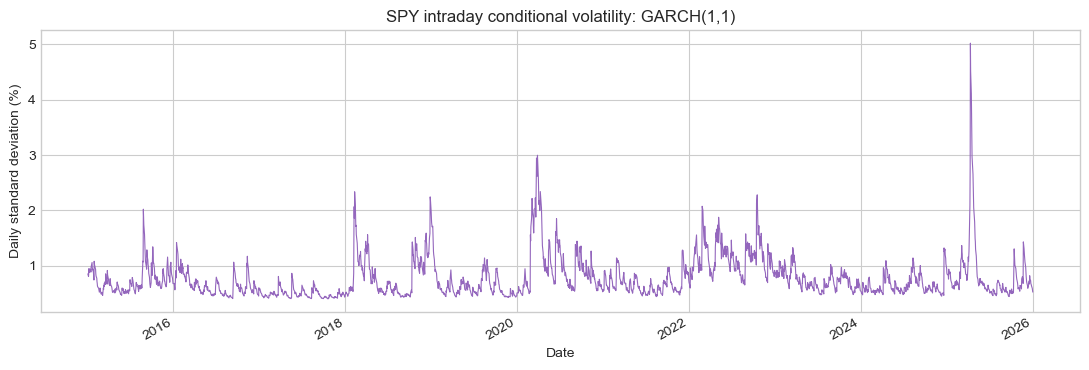

**Interpretation.** GARCH persistence is **0.963** (alpha = 0.170; beta = 0.792). This describes how past shocks and past conditional variance carry into the next day. It is supplementary evidence about volatility clustering, not an estimate of the FOMC announcement effect.

In [17]:
from arch import arch_model

# This univariate model captures volatility clustering. FOMC is not in its variance equation.
intraday_pct = 100 * model_sample["intraday_return"]
garch_fit = arch_model(intraday_pct, mean="Constant", vol="Garch", p=1, q=1,
                       dist="normal").fit(disp="off")
garch_parameters = garch_fit.params.rename("estimate").to_frame()
display(garch_parameters)
garch_parameters.to_csv(TABLE_DIR / "garch_intraday_parameters.csv")
alpha = garch_fit.params["alpha[1]"]
beta_garch = garch_fit.params["beta[1]"]
persistence = alpha + beta_garch
conditional_volatility = pd.Series(garch_fit.conditional_volatility,
                                   index=model_sample.index, name="conditional_volatility_pct")
fig, ax = plt.subplots(figsize=(11, 3.8))
conditional_volatility.plot(ax=ax, color="tab:purple", linewidth=0.8)
ax.set(title="SPY intraday conditional volatility: GARCH(1,1)",
       xlabel="Date", ylabel="Daily standard deviation (%)")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "spy_intraday_garch_volatility.png", dpi=180, bbox_inches="tight")
plt.show()
display(Markdown(
    f"**Interpretation.** GARCH persistence is **{persistence:.3f}** "
    f"(alpha = {alpha:.3f}; beta = {beta_garch:.3f}). "
    "This describes how past shocks and past conditional variance carry into "
    "the next day. It is supplementary evidence about volatility clustering, "
    "not an estimate of the FOMC announcement effect."
))

## 15. Consolidated findings

In [18]:
delta_p = model_1.pvalues["overnight_return:fomc_day"]
fomc_vol_p = model_2.pvalues["fomc_day"]

h2 = "support" if delta_p < 0.05 else "do not support"
h3 = "supported" if (model_2.params["fomc_day"] > 0 and fomc_vol_p < 0.05) else "not supported at the 5% level"

final_findings = pd.DataFrame({
    "Question": [
        "Does the overnight–intraday slope change on FOMC days?",
        "Are absolute intraday returns higher on FOMC days?",
        "Is the key interaction stable across the two subsamples?",
    ],
    "Evidence": [
        f"delta={delta:+.3f}, p={delta_p:.3f}",
        f"effect={vol_effect:+.2f} bp, p={fomc_vol_p:.3f}",
        f"2015–19={pre_delta:+.3f}; 2020–25={post_delta:+.3f}",
    ],
    "Assessment": ["supported at 5%" if delta_p < 0.05 else "not supported at 5%", h3, "same sign" if same_period_sign else "different signs"],
})
display(final_findings)

display(Markdown(
    f"""## Overall interpretation

The main interaction between overnight return and the scheduled-FOMC indicator is **{delta:+.3f}** with a HAC p-value of **{delta_p:.3f}**. Therefore, the data **{h2}** the claim that scheduled announcements change the overnight–intraday relationship at the conventional 5% threshold.

Model 2 estimates an FOMC-day difference of **{vol_effect:+.2f} basis points** in absolute intraday return (p = **{fomc_vol_p:.3f}**), so the hypothesis that scheduled meetings are associated with higher intraday movement is **{h3}**.

These conclusions should emphasize effect sizes, uncertainty and robustness—not only statistical significance. In particular, decision type is an imperfect proxy for monetary-policy news because a hike or cut may have been fully anticipated before the statement.
"""
))

print("Saved processed dataset:", PROCESSED_DIR / "spy_fomc_analysis_2015_2025.csv")
print("Saved model tables:", TABLE_DIR)
print("Saved event-study figure:", FIGURE_DIR / "fomc_event_window.png")

,Question,Evidence,Assessment
0,Does the overnight–intraday slope change on FO...,"delta=+0.192, p=0.430",not supported at 5%
1,Are absolute intraday returns higher on FOMC d...,"effect=+13.42 bp, p=0.049",supported
2,Is the key interaction stable across the two s...,2015–19=-0.136; 2020–25=+0.284,different signs


## Overall interpretation

The main interaction between overnight return and the scheduled-FOMC indicator is **+0.192** with a HAC p-value of **0.430**. Therefore, the data **do not support** the claim that scheduled announcements change the overnight–intraday relationship at the conventional 5% threshold.

Model 2 estimates an FOMC-day difference of **+13.42 basis points** in absolute intraday return (p = **0.049**), so the hypothesis that scheduled meetings are associated with higher intraday movement is **supported**.

These conclusions should emphasize effect sizes, uncertainty and robustness—not only statistical significance. In particular, decision type is an imperfect proxy for monetary-policy news because a hike or cut may have been fully anticipated before the statement.


Saved processed dataset: /Users/admin/Documents/TCH442_Group12/fomc-price-discovery/output/jupyter-notebook/data/processed/spy_fomc_analysis_2015_2025.csv
Saved model tables: /Users/admin/Documents/TCH442_Group12/fomc-price-discovery/output/jupyter-notebook/outputs/tables
Saved event-study figure: /Users/admin/Documents/TCH442_Group12/fomc-price-discovery/output/jupyter-notebook/outputs/figures/fomc_event_window.png


## Remaining checks before submission

- Have all four group members audit the 87 FOMC event dates against the Federal Reserve source URLs saved in the event CSV.
- Add the actual member names and signed contribution paragraphs to the final submission copy.
- Explain the borderline HAC bandwidth sensitivity of Model 2 and the RESET rejection in the report.
- Treat all reported coefficients as conditional associations, not causal effects of a policy surprise.
